# Experiment 1

Here our goal is to establish that the most basic version of the simulation model works, and then to assess the distribution of parameters that lead to stability.


In [1]:
# === IMPORT === #
import numpy as np
import whiterunMarket as wrm  # import shared functions
import experiment1 as e1      # Import functions from experiment1.py
import inspect                # allow us to see function source code in console

sessionLog = wrm.sessionLog   # set alias

## Experiment Class-Object

For this experiment, we set the below world and market parameters and assumed that when a farmer decides to sell wheat or buy bread, the farmer trades all wheat or gold possible in the transaction. Usually, such a decision to transact would be a marginal one--that is, whether to trade one more or one less of an item. In this arrangement, we flatten that choice to a binary, transact or pursue a different action. Moreover, we have not yet introduced an agent on the other side of the transaction. That means that when a farmer decides to transact, the farmer will always be able to sell wheat at a fixed price and buy bread at a fixed price--there is no concern over shortages in wheat, bread or gold.

We impose these simplifying assumptions so that we can ensure the rest of the simulation is working as intended. It is important to note that since a farmer must be able to correctly sequence harvesting wheat, selling wheat and buying bread, a farmer might accrue 4 units of `hunger` before the first time they are able to consume a unit of bread they purchased. To that end, we ensure that farmers start with an inventory to help them through the first several days, and the `STARVATION` threshold is set as to allow some leyway in the production chain.


In [2]:
print(
    'Experiment Parameters:',
    '''
    # ['EXPERIMENT PARAMS']
    VILLAGES   = int(1E3) # number of villages to text
    DAYS       = int(1E3) # number of days to simulate
    
    # ['WORLD PARAMS']
    FARMERS    = 12  # number of farmer per village
    PROD_WHEAT = 3 # amount of wheat produced per production action
    
    # ['MARKET PARAMS']
    PR_BREAD   = 3 # initial price of bread
    PR_WHEAT   = 1 # initial price of wheat

    # ['FARMER PARAMS']
    # Farmer status change parameters
    EXHAUSTION = 1 # amount of hunger gained per production action
    STARVATION = 5 # max amount of hunger allowed before starvation
    RECOVERY   = 0 # eating resets hunger if 0, else reduces hunger
    
    # Initial conditions for farmer agent inventories
    BREAD      = 1
    WHEAT      = 0
    GOLD       = 3
    HUNGER     = 0
    ''',
    inspect.getsource(e1.experiment1),
    sep='\n'
)

Experiment Parameters:

    # ['EXPERIMENT PARAMS']
    VILLAGES   = int(1E3) # number of villages to text
    DAYS       = int(1E3) # number of days to simulate

    # ['WORLD PARAMS']
    FARMERS    = 12  # number of farmer per village
    PROD_WHEAT = 3 # amount of wheat produced per production action

    # ['MARKET PARAMS']
    PR_BREAD   = 3 # initial price of bread
    PR_WHEAT   = 1 # initial price of wheat

    # ['FARMER PARAMS']
    # Farmer status change parameters
    EXHAUSTION = 1 # amount of hunger gained per production action
    STARVATION = 5 # max amount of hunger allowed before starvation
    RECOVERY   = 0 # eating resets hunger if 0, else reduces hunger

    # Initial conditions for farmer agent inventories
    BREAD      = 1
    WHEAT      = 0
    GOLD       = 3
    HUNGER     = 0
    
class experiment1 :
    def __init__(self, func, **kwargs) :
        # Experiment 1 -- Parameters
        #   Include experiment specific parameters specifications, so we can
    

## Preference Parameter distributions

As mentioned previously, the preference parameters are drawn from a non-negative, continuous random distribution. In this experiment we test three distributions: `Log-Normal`, `Gamma` and `Dirichelt`. It is important to note that the `Dirichelt` is a special n-dimensional case of the `Gamma` distribution in which vector components are correlated--that is, the distribution is defined by the normalized vector of the `alpha` parameter for each `Gamma` distribution. As we see later, normalizing the results from the `Gamma` trials produces a near-identical result to the `Dirichelt` distribution.

The `Log-Normal` distribution differs from the `Gamma/Dirichelt` distributions in that it has significantly higher kurtosis. That means that extreme parameter values are relatively more likely. While this difference allows for a wider range of parameters to be consider, as we will see in the results of experiments `1` and `2`, once the results are normalized, the difference disappear.

The parameters for all three distributions were chosen to reflect the closest equivalent to the standard normal for that distribution:
* Log-Normal: $\mu = 0$, $\sigma = 1$
* Gamma: $\alpha = 1$, $\beta = 1$
* Dirichlet: $\vec{\alpha} = [1, 1, 1, 1]$
  

In [10]:
%%capture
####    EXPERIMENT 1    ####
# Experiment 1 A
sessionLog.print('Experiment 1.A (Log-Normal) start')

m = 0
v = 1

exp1a = e1.experiment1(lambda : np.random.lognormal(mean=m, sigma=v, size=4))
exp1a.runSimulation()
sessionLog.print('\n')


[2026-07-12 21:32:23] Experiment 1.A (Log-Normal) start
[2026-07-12 21:32:23] Village 0 complete!
[2026-07-12 21:32:23] Village 1 complete!
[2026-07-12 21:32:23] Village 2 complete!
[2026-07-12 21:32:23] Village 3 complete!
[2026-07-12 21:32:23] Village 4 complete!
[2026-07-12 21:32:23] Village 5 complete!
[2026-07-12 21:32:23] Village 6 complete!
[2026-07-12 21:32:23] Village 7 complete!
[2026-07-12 21:32:23] Village 8 complete!
[2026-07-12 21:32:23] Village 9 complete!
[2026-07-12 21:32:23] Village 10 complete!
[2026-07-12 21:32:23] Village 11 complete!
[2026-07-12 21:32:23] Village 12 complete!
[2026-07-12 21:32:23] Village 13 complete!
[2026-07-12 21:32:23] Village 14 complete!
[2026-07-12 21:32:23] Village 15 complete!
[2026-07-12 21:32:23] Village 16 complete!
[2026-07-12 21:32:23] Village 17 complete!
[2026-07-12 21:32:23] Village 18 complete!
[2026-07-12 21:32:23] Village 19 complete!
[2026-07-12 21:32:23] Village 20 complete!
[2026-07-12 21:32:23] Village 21 complete!
[2026-07

In [11]:
# Experiment 1 B
sessionLog.print('Experiment 1.B (Gamma) start')

alpha = 1
beta  = 1

exp1b = e1.experiment1(lambda : np.random.gamma(alpha,1/beta, size=4))
exp1b.runSimulation()
sessionLog.print('\n')


[2026-07-12 21:33:36] Experiment 1.B (Gamma) start
[2026-07-12 21:33:36] Village 0 complete!
[2026-07-12 21:33:36] Village 1 complete!
[2026-07-12 21:33:36] Village 2 complete!
[2026-07-12 21:33:36] Village 3 complete!
[2026-07-12 21:33:36] Village 4 complete!
[2026-07-12 21:33:37] Village 5 complete!
[2026-07-12 21:33:37] Village 6 complete!
[2026-07-12 21:33:37] Village 7 complete!
[2026-07-12 21:33:37] Village 8 complete!
[2026-07-12 21:33:37] Village 9 complete!
[2026-07-12 21:33:37] Village 10 complete!
[2026-07-12 21:33:37] Village 11 complete!
[2026-07-12 21:33:37] Village 12 complete!
[2026-07-12 21:33:37] Village 13 complete!
[2026-07-12 21:33:37] Village 14 complete!
[2026-07-12 21:33:37] Village 15 complete!
[2026-07-12 21:33:37] Village 16 complete!
[2026-07-12 21:33:37] Village 17 complete!
[2026-07-12 21:33:37] Village 18 complete!
[2026-07-12 21:33:37] Village 19 complete!
[2026-07-12 21:33:37] Village 20 complete!
[2026-07-12 21:33:37] Village 21 complete!
[2026-07-12 2

In [12]:
# Experiment 1 C
sessionLog.print('Experiment 1.C (Dirichlet) start')

exp1c = e1.experiment1(lambda : np.random.dirichlet([1.0,1.0,1.0,1.0]))
exp1c.runSimulation()
sessionLog.print('\n')

####

[2026-07-12 21:33:55] Experiment 1.C (Dirichlet) start
[2026-07-12 21:33:55] Village 0 complete!
[2026-07-12 21:33:55] Village 1 complete!
[2026-07-12 21:33:55] Village 2 complete!
[2026-07-12 21:33:56] Village 3 complete!
[2026-07-12 21:33:56] Village 4 complete!
[2026-07-12 21:33:56] Village 5 complete!
[2026-07-12 21:33:56] Village 6 complete!
[2026-07-12 21:33:56] Village 7 complete!
[2026-07-12 21:33:56] Village 8 complete!
[2026-07-12 21:33:56] Village 9 complete!
[2026-07-12 21:33:56] Village 10 complete!
[2026-07-12 21:33:56] Village 11 complete!
[2026-07-12 21:33:56] Village 12 complete!
[2026-07-12 21:33:56] Village 13 complete!
[2026-07-12 21:33:56] Village 14 complete!
[2026-07-12 21:33:56] Village 15 complete!
[2026-07-12 21:33:56] Village 16 complete!
[2026-07-12 21:33:56] Village 17 complete!
[2026-07-12 21:33:56] Village 18 complete!
[2026-07-12 21:33:56] Village 19 complete!
[2026-07-12 21:33:56] Village 20 complete!
[2026-07-12 21:33:56] Village 21 complete!
[2026-07-

## Results

To assess the outcome of the simulation trials, we look at surival rates under each distribution, the means of each parameter controlling for distribution, farmer survival, and before and after normalizing.

We plot histograms for trial survival duration, and parameter frequency across survival status.


[2026-07-12 21:30:45] Experiment run complete; starting evaluation of results.
[2026-07-12 21:30:45] 
 Log-Normal (1) survival rate: 2.64 %
 survivors, mean params:
            gamma     omega      beta       eta
status                                        
0       1.674316  1.637598  1.565262  1.688008
1       1.386161  0.725113  5.616000  0.485411


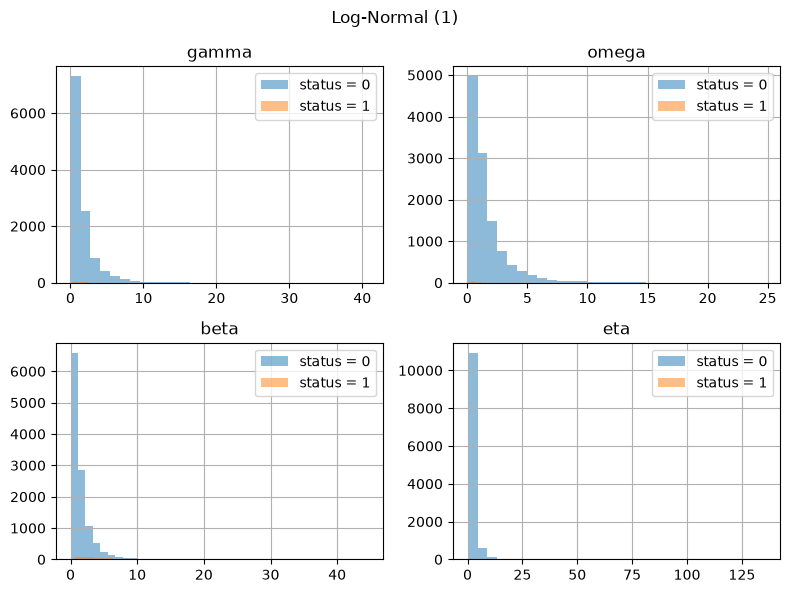

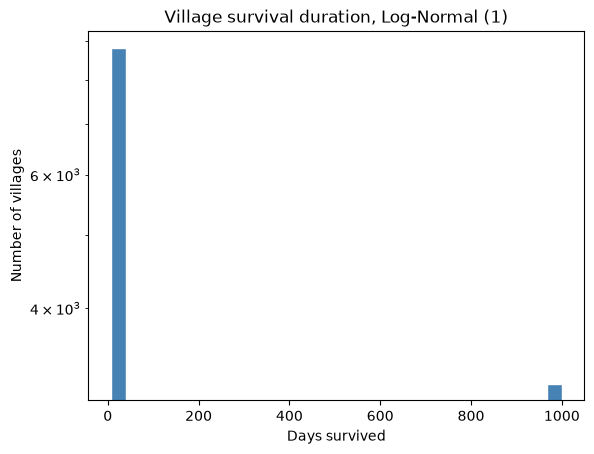

[2026-07-12 21:30:46] 
 Log-Normal (1) (norm.) survival rate: 2.64 %
 survivors, mean params:
            gamma     omega      beta       eta
status                                        
0       0.252049  0.252183  0.239440  0.256329
1       0.186672  0.105273  0.632772  0.075283


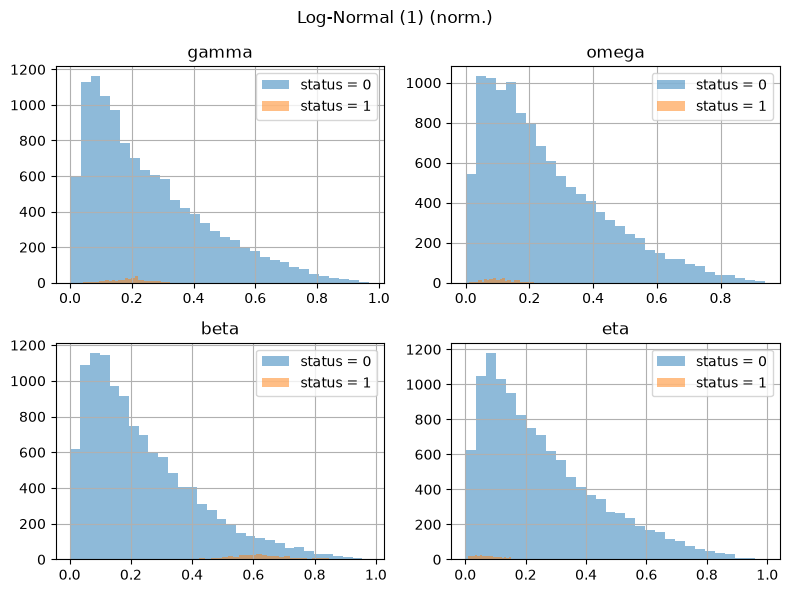

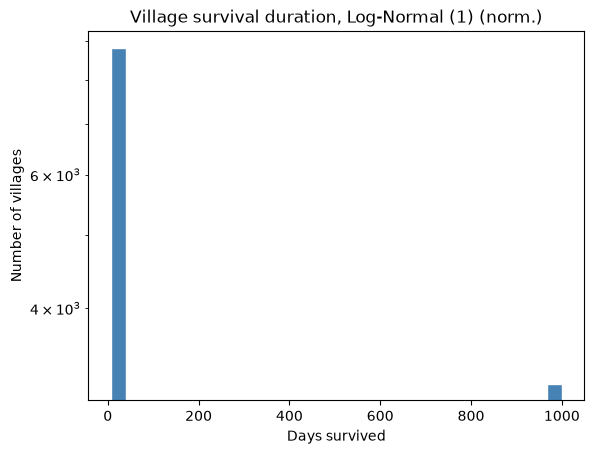

In [6]:
####    EXPERIMENT RESULTS  ####
sessionLog.print('Experiment run complete; starting evaluation of results.')

# Experiment 1a Result EDA
wrm.post_exp_eda1(exp1a.outcome, 'Log-Normal (1)')
exp1a.outcome[wrm.PARAMS] = (
    exp1a.outcome[wrm.PARAMS].div(exp1a.outcome[wrm.PARAMS].sum(axis=1), axis=0)
    )
wrm.post_exp_eda1(exp1a.outcome, 'Log-Normal (1) (norm.)')


[2026-07-12 21:30:47] 
 Gamma (1) survival rate: 2.28 %
 survivors, mean params:
            gamma     omega      beta       eta
status                                        
0       0.994424  1.020268  0.953632  1.012696
1       0.818767  0.408046  2.539028  0.273312


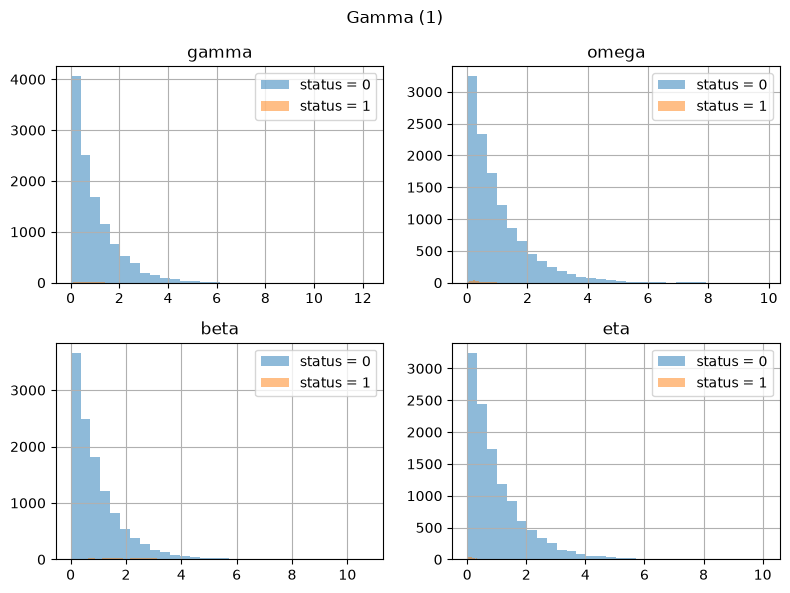

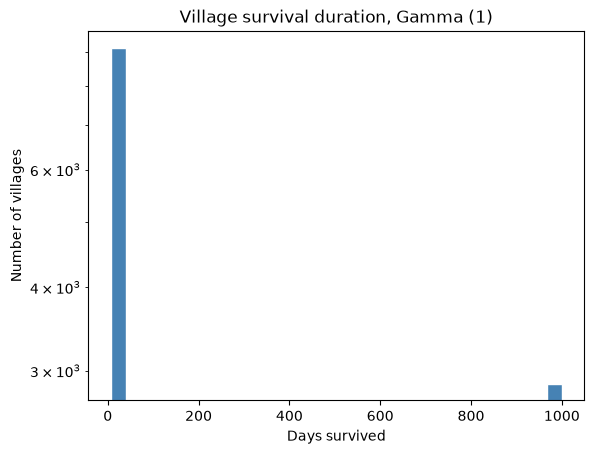

[2026-07-12 21:30:49] 
 Gamma (1) (norm.) survival rate: 2.28 %
 survivors, mean params:
            gamma     omega      beta       eta
status                                        
0       0.251233  0.253876  0.240285  0.254607
1       0.201949  0.102263  0.628738  0.067050


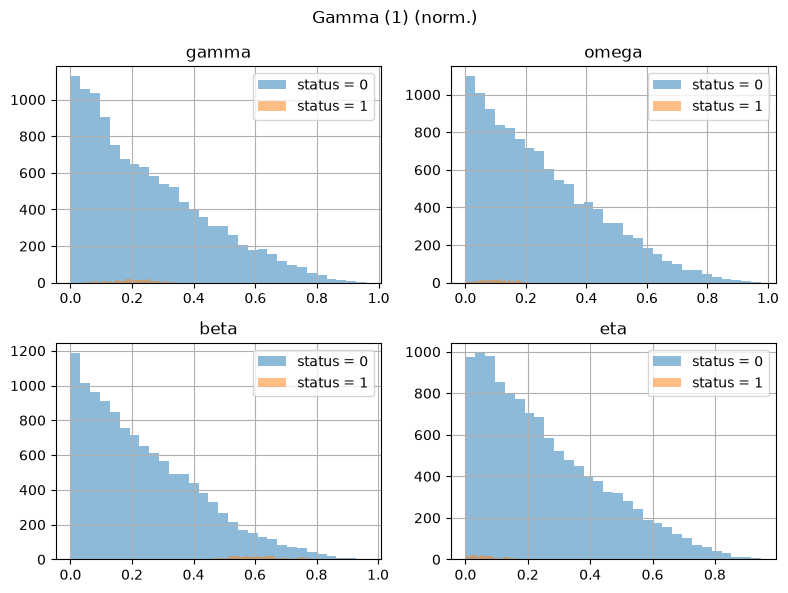

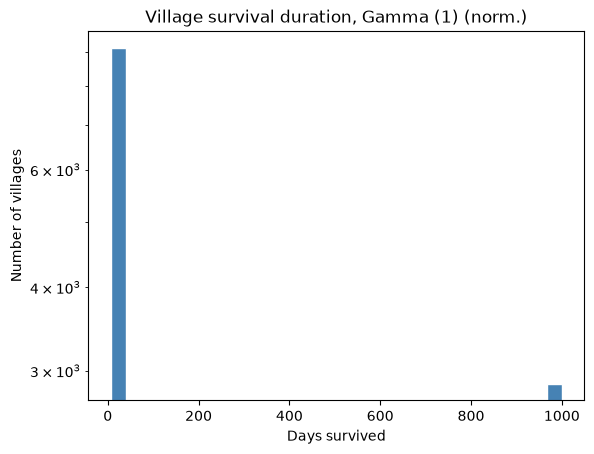

In [7]:
# Experiment 1b Result EDA
wrm.post_exp_eda1(exp1b.outcome, 'Gamma (1)')
exp1b.outcome[wrm.PARAMS] = (
    exp1b.outcome[wrm.PARAMS].div(exp1b.outcome[wrm.PARAMS].sum(axis=1), axis=0)
    )
wrm.post_exp_eda1(exp1b.outcome, 'Gamma (1) (norm.)')


[2026-07-12 21:30:50] 
 Dirichlet (1) survival rate: 2.07 %
 survivors, mean params:
            gamma     omega      beta       eta
status                                        
0       0.251699  0.251305  0.243674  0.253321
1       0.197145  0.105078  0.632701  0.065076


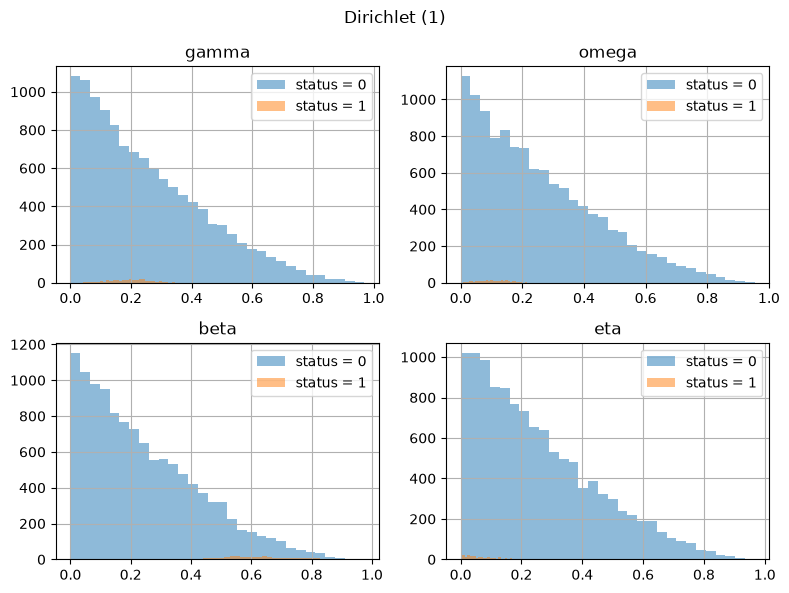

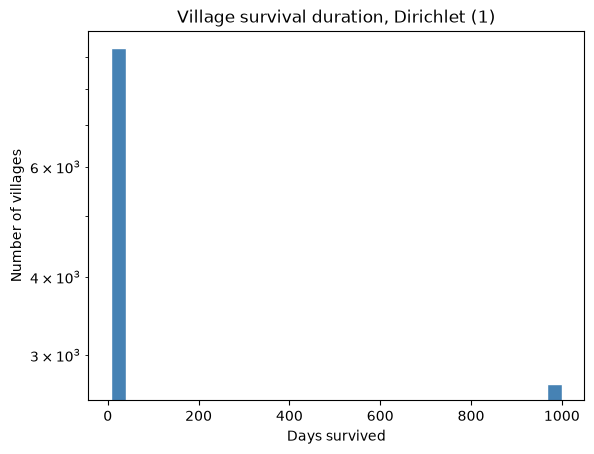

[2026-07-12 21:30:51] 
 Dirichlet (1) (norm.) survival rate: 2.07 %
 survivors, mean params:
            gamma     omega      beta       eta
status                                        
0       0.251699  0.251305  0.243674  0.253321
1       0.197145  0.105078  0.632701  0.065076


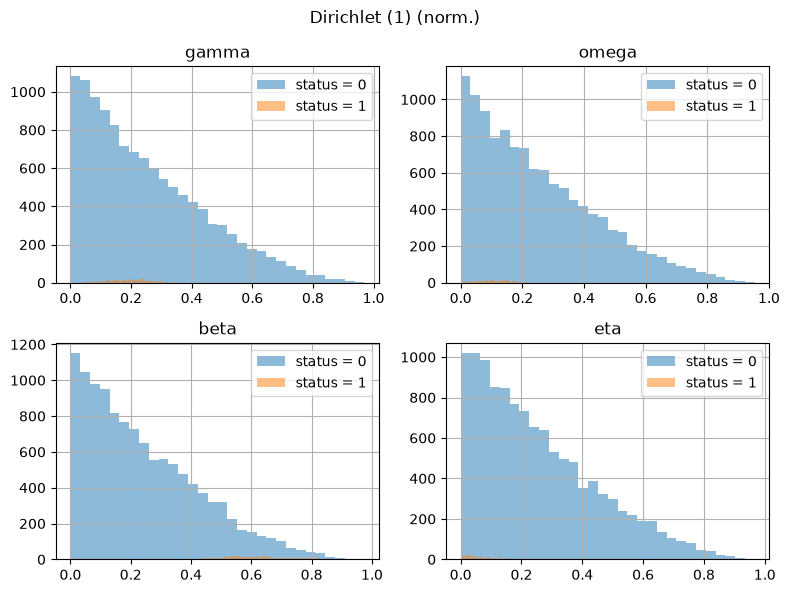

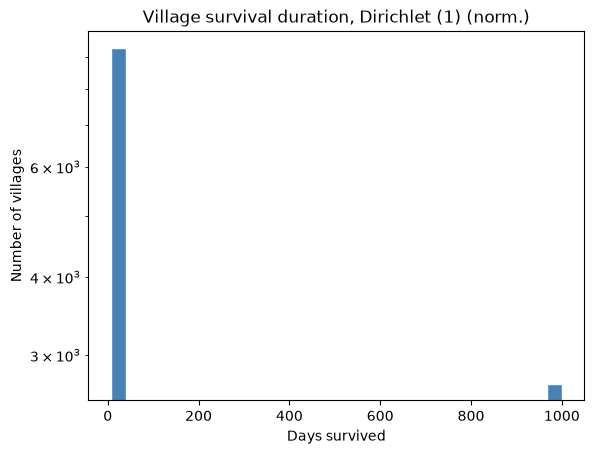

In [8]:
# Experiment 1c Result EDA
wrm.post_exp_eda1(exp1c.outcome, 'Dirichlet (1)')
exp1c.outcome[wrm.PARAMS] = (
    exp1c.outcome[wrm.PARAMS].div(exp1c.outcome[wrm.PARAMS].sum(axis=1), axis=0)
    )
wrm.post_exp_eda1(exp1c.outcome, 'Dirichlet (1) (norm.)')


## Discussion

As shown above, the survival rate of farmers tends to fall between 2% and 2.5%.

From the survival duration charts, we are able to see that all villages that failed did so before the hundreth time-step. This provides strong evidence that if a village (in this case, could be a single farmer) makes it to the 1,000th time-step, then they likely are stable enough to continue indefinitely.

Perhaps the most interesting result to note is that after normalizing the preference parameters, the mean values for survivors were incredibly close.

* $\gamma \approx 0.20$ (gold)
* $\omega \approx 0.10$ (wheat)
* $\beta \approx 0.635$ (bread)
* $\eta \approx 0.065$ (hunger)

Microeconomic theory supports these observations: while not percise, after normalizing, we can think of these terms as the marginal rate of substitution for each item. So, amongst successful farmers, on average gold is preferred twice as much as wheat, and bread is preferred to gold three times as much. Hunger holds some sway--recall that the only decision that directly effected hunger was harvesting wheat--however, our current simulation framework may not be sufficient for capturing the role of a hunger parameter.
